# alpha.ipynb — rwrt Benchmark Suite

**Right Word at the Right Time** — adaptive Turkish vocabulary recommendation benchmark.

Evaluates how well each pipeline configuration recommends **semantically and morphologically
related** unknown words given a set of known words.

### Metrics

| Metric | Key | What it measures |
|--------|-----|------------------|
| **Combined score** | `combined_score` | 0.35*S + 0.35*F + 0.10*M + 0.15*D − 0.05*E |
| Semantic coherence | `semantic_coherence` | Mean cos between recs and known centroid |
| Frequency | `frequency` | Mean normalized log-frequency of recs |
| Stem diversity (M) | `stem_diversity` | Unique morphological stems / K |
| Rec diversity (D) | `rec_diversity` | 1 − mean pairwise cosine among recs |
| Difficulty penalty | `difficulty_penalty` | Fraction of recs in bottom frequency quartile |

### Methods compared

| Method | Description |
|--------|-------------|
| `bi_only` | Bi-encoder + FAISS inner-product search |
| `bi_cross` | Bi-encoder retrieval + cross-encoder reranking |
| `weighted_feature` | Bi-encoder + multi-objective feature scorer (semantic + frequency + morphology + diversity) |

Results are saved to `data/faiss_alpha/benchmark_results.json`.

---
**VRAM note:** designed for 8 GB GPUs. Models load one at a time; GPU memory is
cleared between experiments. Batch sizes are conservative.

In [1]:
import json
import math
import sys
import gc
import time
import itertools
import random
from pathlib import Path
from typing import Any
from collections import defaultdict

import faiss
import numpy as np
import torch

from rwrt.config import PipelineConfig
from rwrt.vocabulary import VocabularyStore
from rwrt.index import EmbeddingIndex
from rwrt.retrieve import BiEncoderRetriever
from rwrt.rerank import CrossEncoderReranker
from rwrt.types import Candidate
from rwrt.encoders import clear_encoder_cache

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

rng = random.Random(42)

print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"FAISS: {faiss.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    print(f"VRAM: {props.total_memory / 1e9:.1f} GB")

Python: 3.12.7 (main, Mar 25 2026, 14:45:05) [GCC 15.2.1 20260123 (Red Hat 15.2.1-7)]
PyTorch: 2.11.0+cu130
FAISS: 1.13.2
CUDA available: True
Device: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.2 GB


In [2]:
# =====================================================================
# CONFIGURATION  —  edit this cell before running
# =====================================================================

# --- Paths ---
DB_PATH = Path("primary_graph.sqlite")
RESULTS_DIR = Path("data/faiss_alpha")
INDEX_BASE = Path("data/faiss")

# --- Vocabulary ---
MIN_WEIGHT = 10
MAX_VOCAB: int | None = 50_000       # None = use full vocabulary

# --- Learner simulation ---
# For each profile, we sample *profile_size* known words from across
# all frequency bands, then measure how semantically/morphologically
# related the recommendations are to those known words.
PROFILE_SIZES = [10, 25, 50, 100, 200, 500]
NUM_PROFILES_PER_SIZE = 5            # multiple random draws per size
RETURN_N = 10                         # evaluate at top 10

# --- Retrieval ---
RETRIEVE_K = 200                      # candidates from FAISS before reranking
ENCODE_BATCH_SIZE = 256
CROSS_BATCH_SIZE = 32

# --- Device ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_FAISS_GPU = False                 # toggle FAISS GPU (not needed for 50k)

# --- Models ---
BI_ENCODERS = [
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    "sentence-transformers/distiluse-base-multilingual-cased-v2",
    "intfloat/multilingual-e5-small",
]
CROSS_ENCODER = "dbmdz/bert-base-turkish-cased"

# --- Reranker methods to test ---
# "bi_only" is always included as baseline
# "weighted_feature" is cheap, tested on all models
# "cross_encoder" is expensive (VRAM), tested only on CROSS_ENCODER_MODELS
RERANKER_TYPES = ["weighted_feature", "cross_encoder"]
CROSS_ENCODER_MODELS = [
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    "sentence-transformers/distiluse-base-multilingual-cased-v2",
]

# --- Query strategies to test ---
QUERY_STRATEGIES = [
    "mean_embedding",
    "weighted_mean",
    "inverse_weighted_mean",
]

# --- Topic exploration ---
TOPIC_KEYWORDS = ["yemek", "seyahat", "okul", "aile", "iş"]

# --- Misc ---
FORCE_REBUILD = False                 # rebuild all indices even if cached

# --- Derived ---
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
INDEX_BASE.mkdir(parents=True, exist_ok=True)
print("Configuration loaded.")
print(f"  Device:           {DEVICE}")
print(f"  Bi-encoders:      {BI_ENCODERS}")
print(f"  Query strategies: {QUERY_STRATEGIES}")
print(f"  Profile sizes:    {PROFILE_SIZES}")
print(f"  Draws per size:   {NUM_PROFILES_PER_SIZE}")

Configuration loaded.
  Device:           cuda
  Bi-encoders:      ['sentence-transformers/paraphrase-multilingual-mpnet-base-v2', 'sentence-transformers/distiluse-base-multilingual-cased-v2', 'intfloat/multilingual-e5-small']
  Query strategies: ['mean_embedding', 'weighted_mean', 'inverse_weighted_mean']
  Profile sizes:    [10, 25, 50, 100, 200, 500]
  Draws per size:   5


In [3]:
# =====================================================================
# Load vocabulary
# =====================================================================

cfg = PipelineConfig(
    db_path=DB_PATH,
    min_weight=MIN_WEIGHT,
    max_vocab_size=MAX_VOCAB,
    device=DEVICE,
    encode_batch_size=ENCODE_BATCH_SIZE,
    retrieve_k=RETRIEVE_K,
    return_n=RETURN_N,
    cross_batch_size=CROSS_BATCH_SIZE,
).resolve()

vocab = VocabularyStore(cfg)
vocab.load()
all_words = vocab.words()
freqs = [vocab.frequency(w) or 0 for w in all_words]

print(f"Vocabulary: {len(all_words):,} words")
print(f"  Min weight: {MIN_WEIGHT}")
print(f"  Max vocab:  {MAX_VOCAB or 'unlimited'}")
print(f"  Freq range: {min(freqs):,} – {max(freqs):,}")
print(f"  Top 10:     {all_words[:10]}")

# Frequency constants for metric computation
MAX_FREQ = max(freqs)
BOTTOM_QUARTILE_IDX = 3 * len(all_words) // 4
BOTTOM_QUARTILE_FREQ = freqs[BOTTOM_QUARTILE_IDX]

Vocabulary: 50,000 words
  Min weight: 10
  Max vocab:  50000
  Freq range: 781 – 18,901,536
  Top 10:     ['bir', 'bu', 'ne', 've', 'için', 'mi', 'o', 'de', 'ben', 'çok']


In [4]:
# =====================================================================
# Metrics — multi-objective evaluation
# =====================================================================
# Combined score: 0.35*S + 0.35*F + 0.10*M + 0.15*D - 0.05*E
# S = semantic_coherence, F = frequency, M = stem_diversity,
# D = rec_diversity, E = difficulty_penalty
# Higher combined = better. Sub-metrics for diagnosis.

def _common_prefix_ratio(w1: str, w2: str) -> float:
    min_len = min(len(w1), len(w2))
    if min_len < 3:
        return 0.0
    common = 0
    for a, b in zip(w1.lower(), w2.lower()):
        if a == b:
            common += 1
        else:
            break
    return common / min_len


def _stem_group_idx(word: str, groups: list[list[str]]) -> int:
    for i, g in enumerate(groups):
        for gw in g:
            if _common_prefix_ratio(word, gw) >= 0.4:
                return i
    return -1


def semantic_coherence(recommended, known_set, index, k=10):
    """S: mean cos similarity between recs and known-word centroid."""
    top = recommended[:k]
    if not top or not known_set:
        return 0.0
    known_in_idx = [w for w in known_set if w in index._word_to_idx]
    if not known_in_idx:
        return 0.0
    try:
        vecs = np.stack([index.embedding_for(w) for w in known_in_idx])
        centroid = vecs.mean(axis=0)
        centroid /= np.linalg.norm(centroid) + 1e-10
        scores = []
        for w in top:
            if w in index._word_to_idx:
                sim = float(np.dot(index.embedding_for(w), centroid))
                scores.append(sim)
        return sum(scores) / len(scores) if scores else 0.0
    except (KeyError, ValueError):
        return 0.0


def frequency_appropriateness(recommended, k=10):
    """F: mean normalized log-frequency (higher = more common, appropriate)."""
    top = recommended[:k]
    if not top:
        return 0.0
    max_lf = np.log1p(MAX_FREQ)
    scores = []
    for w in top:
        f = vocab.frequency(w) or 0
        scores.append(np.log1p(f) / max_lf)
    return float(sum(scores) / len(scores))


def stem_diversity(recommended, k=10):
    """M: unique morphological stems / K (high = morphologically diverse = good)."""
    top = recommended[:k]
    if not top:
        return 0.0
    groups = []
    for w in top:
        idx = _stem_group_idx(w, groups)
        if idx >= 0:
            groups[idx].append(w)
        else:
            groups.append([w])
    return len(groups) / len(top)


def rec_diversity(recommended, index, k=10):
    """D: 1 - mean pairwise cosine among recs (high = diverse = good)."""
    top = recommended[:k]
    if not top:
        return 0.0
    vecs = []
    for w in top:
        if w in index._word_to_idx:
            vecs.append(index.embedding_for(w))
    if len(vecs) < 2:
        return 1.0
    vecs = np.stack(vecs)
    vecs /= np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-10
    sim = vecs @ vecs.T
    n = len(vecs)
    total = sim.sum() - n
    count = n * (n - 1)
    mean_sim = total / count if count else 0.0
    return float(1.0 - mean_sim)


def difficulty_penalty(recommended, k=10):
    """E: fraction of recs in bottom frequency quartile (high = too rare = bad)."""
    top = recommended[:k]
    if not top:
        return 0.0
    bottom = sum(1 for w in top if (vocab.frequency(w) or 0) <= BOTTOM_QUARTILE_FREQ)
    return bottom / len(top)


def compute_metrics(words, known_set, index, k=10):
    S = semantic_coherence(words, known_set, index, k)
    F = frequency_appropriateness(words, k)
    M = stem_diversity(words, k)
    D = rec_diversity(words, index, k)
    E = difficulty_penalty(words, k)
    combined = 0.35*S + 0.35*F + 0.10*M + 0.15*D - 0.05*E
    return {
        "combined_score": combined,
        "semantic_coherence": S,
        "frequency": F,
        "stem_diversity": M,
        "rec_diversity": D,
        "difficulty_penalty": E,
    }

In [5]:
# =====================================================================
# Profile simulation
# =====================================================================

# Divide vocabulary into frequency quartiles for stratified sampling
n = len(all_words)
q1 = all_words[:n // 4]
q2 = all_words[n // 4: n // 2]
q3 = all_words[n // 2: 3 * n // 4]
q4 = all_words[3 * n // 4:]
quartiles = [q1, q2, q3, q4]
print(f"Frequency quartile sizes: {[len(q) for q in quartiles]}")


def sample_profile(profile_size: int, rng: random.Random) -> set[str]:
    """Sample *profile_size* known words stratified across all frequency bands."""
    per_quartile = max(1, profile_size // 4)
    known: set[str] = set()
    for q in quartiles:
        pool = [w for w in q if w not in known]
        if not pool:
            continue
        taken = rng.sample(pool, min(per_quartile, len(pool)))
        known.update(taken)
    # Fill remaining if short
    remaining = [w for w in all_words if w not in known]
    rng.shuffle(remaining)
    need = profile_size - len(known)
    if need > 0 and remaining:
        known.update(remaining[:need])
    return known


# Generate all profiles once
profiles: list[dict[str, Any]] = []
for size in PROFILE_SIZES:
    for _ in range(NUM_PROFILES_PER_SIZE):
        known = sample_profile(size, rng)
        profiles.append({
            "profile_size": size,
            "known": known,
        })

print(f"Generated {len(profiles)} profiles:")
by_size = defaultdict(int)
for p in profiles:
    by_size[p["profile_size"]] += 1
for size, count in sorted(by_size.items()):
    print(f"  {size:>4} known words  x  {count} draws")

Frequency quartile sizes: [12500, 12500, 12500, 12500]
Generated 30 profiles:
    10 known words  x  5 draws
    25 known words  x  5 draws
    50 known words  x  5 draws
   100 known words  x  5 draws
   200 known words  x  5 draws
   500 known words  x  5 draws


In [6]:
# =====================================================================
# Single-model index builder (build once, cache per model)
# =====================================================================

def _model_slug(model_name: str) -> str:
    return model_name.replace("/", "_").replace("-", "_")


def build_or_load_index(
    bi_model: str,
    vocab: VocabularyStore,
    base_cfg: PipelineConfig,
    force_rebuild: bool = False,
) -> tuple[EmbeddingIndex, PipelineConfig]:
    """Build (or load cached) FAISS index for *bi_model*."""
    index_dir = INDEX_BASE / _model_slug(bi_model)
    model_cfg = PipelineConfig(
        db_path=base_cfg.db_path,
        index_dir=index_dir,
        min_weight=base_cfg.min_weight,
        max_vocab_size=base_cfg.max_vocab_size,
        bi_model=bi_model,
        device=base_cfg.device,
        encode_batch_size=base_cfg.encode_batch_size,
    ).resolve()

    index = EmbeddingIndex(model_cfg, vocab)
    if not index.is_built or force_rebuild:
        print(f"  Building index: {bi_model}...")
        t0 = time.time()
        index.build(save_embeddings=True)
        elapsed = time.time() - t0
        print(f"  Done ({elapsed:.1f}s). Index: {index_dir / 'index.faiss'}")
    else:
        print(f"  Loading cached index: {bi_model}...")
        index.load()

    return index, model_cfg

In [7]:
# =====================================================================
# Experiment runner
# =====================================================================

def run_experiment(
    bi_model: str,
    query_strategy: str,
    reranker_type: str,
    profiles: list[dict[str, Any]],
    vocab: VocabularyStore,
    base_cfg: PipelineConfig,
    force_rebuild: bool = False,
) -> list[dict[str, Any]]:
    """Run one experiment configuration over all profiles.

    *reranker_type*: "none" (bi_only), "weighted_feature", or "cross_encoder".
    Returns combined score + 5 sub-metrics per method.
    """
    clear_encoder_cache()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    index, model_cfg = build_or_load_index(
        bi_model, vocab, base_cfg, force_rebuild=force_rebuild
    )

    model_cfg.query_strategy = query_strategy  # type: ignore[assignment]
    model_cfg.retrieve_k = RETRIEVE_K
    model_cfg.return_n = RETURN_N
    model_cfg.cross_batch_size = CROSS_BATCH_SIZE
    model_cfg.reranker_type = reranker_type

    retriever = BiEncoderRetriever(model_cfg, vocab, index)
    if reranker_type == "cross_encoder":
        from rwrt.rerank import CrossEncoderReranker as RerankerCls
        reranker = RerankerCls(model_cfg, vocabulary=vocab, index=index)
    elif reranker_type == "weighted_feature":
        from rwrt.rerank import WeightedFeatureReranker as RerankerCls
        reranker = RerankerCls(model_cfg, vocabulary=vocab, index=index)
    else:
        reranker = None

    results = []
    for p in profiles:
        known = p["known"]

        t0 = time.time()
        candidates = retriever.retrieve(known, k=RETRIEVE_K)

        # Bi-encoder only ranking (baseline)
        candidates.sort(key=lambda c: c.final_score, reverse=True)
        bi_words = [c.word for c in candidates[:RETURN_N]]

        # Reranked (if applicable)
        if reranker is not None:
            ranked = reranker.rerank(known, candidates, n=RETURN_N)
            reranked_words = [c.word for c in ranked]
        else:
            reranked_words = []

        elapsed = time.time() - t0

        bi_metrics = compute_metrics(bi_words, known, index, RETURN_N)

        result: dict[str, Any] = {
            "profile_size": p["profile_size"],
            "elapsed_s": round(elapsed, 3),
            "bi_only": {
                "words": bi_words[:5],
                **bi_metrics,
            },
        }

        if reranked_words:
            rr_metrics = compute_metrics(reranked_words, known, index, RETURN_N)
            result[reranker_type] = {
                "words": reranked_words[:5],
                **rr_metrics,
            }

        results.append(result)

    clear_encoder_cache()
    del index, retriever, reranker
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return results


In [8]:
# =====================================================================
# Run all experiments
# =====================================================================

experiments = []
for bi_model in BI_ENCODERS:
    for qs in QUERY_STRATEGIES:
        # bi_only (no reranker) — always included as baseline
        experiments.append({
            "bi_model": bi_model,
            "query_strategy": qs,
            "reranker_type": "none",
        })
        # weighted_feature — cheap, test on all models
        experiments.append({
            "bi_model": bi_model,
            "query_strategy": qs,
            "reranker_type": "weighted_feature",
        })
        # cross_encoder — expensive, only on allowed models
        if bi_model in CROSS_ENCODER_MODELS:
            experiments.append({
                "bi_model": bi_model,
                "query_strategy": qs,
                "reranker_type": "cross_encoder",
            })

total = len(experiments)
print(f"Total experiment configs: {total}")

all_results: list[dict[str, Any]] = []

for i, exp in enumerate(experiments, 1):
    label = (
        f"[{i}/{total}] "
        f"{exp['bi_model'].split('/')[-1]:45} "
        f"qs={exp['query_strategy']:25} "
        f"rerank={exp['reranker_type']}"
    )
    print(f"\n{'=' * 100}")
    print(f"  {label}")
    print(f"{'=' * 100}")

    try:
        per_profile = run_experiment(
            bi_model=exp["bi_model"],
            query_strategy=exp["query_strategy"],
            reranker_type=exp["reranker_type"],
            profiles=profiles,
            vocab=vocab,
            base_cfg=cfg,
            force_rebuild=FORCE_REBUILD,
        )
    except Exception as exc:
        print(f"  FAILED: {exc}")
        import traceback
        traceback.print_exc()
        continue

    for r in per_profile:
        r["bi_model"] = exp["bi_model"]
        r["query_strategy"] = exp["query_strategy"]
        r["reranker_type"] = exp["reranker_type"]
        all_results.append(r)

    # Quick per-profile summary
    for r in per_profile:
        bi_comb = r["bi_only"]["combined_score"]
        bi_sem = r["bi_only"]["semantic_coherence"]
        extra = ""
        rt = exp["reranker_type"]
        if rt != "none" and rt in r:
            extra = f"  {rt}_comb={r[rt]['combined_score']:.3f}  {rt}_sem={r[rt]['semantic_coherence']:.3f}"
        print(f"    profile={r['profile_size']:>3}:  comb={bi_comb:.3f}  sem={bi_sem:.3f}{extra}")


Total experiment configs: 24

  [1/24] paraphrase-multilingual-mpnet-base-v2         qs=mean_embedding            rerank=none
  Loading cached index: sentence-transformers/paraphrase-multilingual-mpnet-base-v2...
    profile= 10:  comb=0.581  sem=0.938
    profile= 10:  comb=0.591  sem=0.920
    profile= 10:  comb=0.586  sem=0.942
    profile= 10:  comb=0.593  sem=0.935
    profile= 10:  comb=0.599  sem=0.942
    profile= 25:  comb=0.630  sem=0.963
    profile= 25:  comb=0.598  sem=0.952
    profile= 25:  comb=0.612  sem=0.971
    profile= 25:  comb=0.564  sem=0.966
    profile= 25:  comb=0.620  sem=0.965
    profile= 50:  comb=0.601  sem=0.968
    profile= 50:  comb=0.596  sem=0.972
    profile= 50:  comb=0.608  sem=0.972
    profile= 50:  comb=0.596  sem=0.972
    profile= 50:  comb=0.609  sem=0.971
    profile=100:  comb=0.582  sem=0.973
    profile=100:  comb=0.596  sem=0.976
    profile=100:  comb=0.602  sem=0.975
    profile=100:  comb=0.614  sem=0.980
    profile=100:  comb=0.59

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    profile= 10:  comb=0.581  sem=0.938  cross_encoder_comb=0.572  cross_encoder_sem=0.917
    profile= 10:  comb=0.591  sem=0.920  cross_encoder_comb=0.561  cross_encoder_sem=0.903
    profile= 10:  comb=0.586  sem=0.942  cross_encoder_comb=0.568  cross_encoder_sem=0.921
    profile= 10:  comb=0.593  sem=0.935  cross_encoder_comb=0.570  cross_encoder_sem=0.919
    profile= 10:  comb=0.599  sem=0.942  cross_encoder_comb=0.556  cross_encoder_sem=0.926
    profile= 25:  comb=0.630  sem=0.963  cross_encoder_comb=0.567  cross_encoder_sem=0.944
    profile= 25:  comb=0.598  sem=0.952  cross_encoder_comb=0.543  cross_encoder_sem=0.939
    profile= 25:  comb=0.612  sem=0.971  cross_encoder_comb=0.568  cross_encoder_sem=0.959
    profile= 25:  comb=0.564  sem=0.966  cross_encoder_comb=0.591  cross_encoder_sem=0.948
    profile= 25:  comb=0.620  sem=0.965  cross_encoder_comb=0.565  cross_encoder_sem=0.950
    profile= 50:  comb=0.601  sem=0.968  cross_encoder_comb=0.595  cross_encoder_sem=0.954

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    profile= 10:  comb=0.467  sem=0.851  cross_encoder_comb=0.550  cross_encoder_sem=0.872
    profile= 10:  comb=0.540  sem=0.848  cross_encoder_comb=0.549  cross_encoder_sem=0.888
    profile= 10:  comb=0.488  sem=0.805  cross_encoder_comb=0.550  cross_encoder_sem=0.871
    profile= 10:  comb=0.598  sem=0.908  cross_encoder_comb=0.558  cross_encoder_sem=0.898
    profile= 10:  comb=0.563  sem=0.905  cross_encoder_comb=0.572  cross_encoder_sem=0.870
    profile= 25:  comb=0.610  sem=0.947  cross_encoder_comb=0.583  cross_encoder_sem=0.938
    profile= 25:  comb=0.585  sem=0.925  cross_encoder_comb=0.557  cross_encoder_sem=0.928
    profile= 25:  comb=0.594  sem=0.946  cross_encoder_comb=0.566  cross_encoder_sem=0.941
    profile= 25:  comb=0.594  sem=0.961  cross_encoder_comb=0.587  cross_encoder_sem=0.949
    profile= 25:  comb=0.589  sem=0.950  cross_encoder_comb=0.580  cross_encoder_sem=0.945
    profile= 50:  comb=0.643  sem=0.933  cross_encoder_comb=0.614  cross_encoder_sem=0.936

...

    profile= 10:  comb=0.580  sem=0.939  cross_encoder_comb=0.568  cross_encoder_sem=0.921
    profile= 10:  comb=0.590  sem=0.942  cross_encoder_comb=0.578  cross_encoder_sem=0.929
    profile= 10:  comb=0.587  sem=0.922  cross_encoder_comb=0.552  cross_encoder_sem=0.908
    profile= 10:  comb=0.596  sem=0.947  cross_encoder_comb=0.581  cross_encoder_sem=0.933
    profile= 10:  comb=0.563  sem=0.936  cross_encoder_comb=0.567  cross_encoder_sem=0.923
    profile= 25:  comb=0.591  sem=0.960  cross_encoder_comb=0.605  cross_encoder_sem=0.949
    profile= 25:  comb=0.583  sem=0.956  cross_encoder_comb=0.584  cross_encoder_sem=0.945
    profile= 25:  comb=0.605  sem=0.963  cross_encoder_comb=0.583  cross_encoder_sem=0.951
    profile= 25:  comb=0.586  sem=0.962  cross_encoder_comb=0.592  cross_encoder_sem=0.943
    profile= 25:  comb=0.573  sem=0.953  cross_encoder_comb=0.605  cross_encoder_sem=0.941
    profile= 50:  comb=0.585  sem=0.963  cross_encoder_comb=0.593  cross_encoder_sem=0.950

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    profile= 10:  comb=0.489  sem=0.912  cross_encoder_comb=0.547  cross_encoder_sem=0.897
    profile= 10:  comb=0.522  sem=0.835  cross_encoder_comb=0.593  cross_encoder_sem=0.921
    profile= 10:  comb=0.434  sem=0.690  cross_encoder_comb=0.493  cross_encoder_sem=0.702
    profile= 10:  comb=0.561  sem=0.931  cross_encoder_comb=0.559  cross_encoder_sem=0.925
    profile= 10:  comb=0.590  sem=0.877  cross_encoder_comb=0.576  cross_encoder_sem=0.885
    profile= 25:  comb=0.576  sem=0.949  cross_encoder_comb=0.577  cross_encoder_sem=0.949
    profile= 25:  comb=0.602  sem=0.947  cross_encoder_comb=0.562  cross_encoder_sem=0.931
    profile= 25:  comb=0.572  sem=0.938  cross_encoder_comb=0.583  cross_encoder_sem=0.919
    profile= 25:  comb=0.592  sem=0.956  cross_encoder_comb=0.572  cross_encoder_sem=0.947
    profile= 25:  comb=0.597  sem=0.933  cross_encoder_comb=0.571  cross_encoder_sem=0.929
    profile= 50:  comb=0.617  sem=0.877  cross_encoder_comb=0.567  cross_encoder_sem=0.892

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    profile= 10:  comb=0.564  sem=0.926  cross_encoder_comb=0.577  cross_encoder_sem=0.903
    profile= 10:  comb=0.570  sem=0.940  cross_encoder_comb=0.588  cross_encoder_sem=0.928
    profile= 10:  comb=0.529  sem=0.904  cross_encoder_comb=0.590  cross_encoder_sem=0.900
    profile= 10:  comb=0.576  sem=0.938  cross_encoder_comb=0.550  cross_encoder_sem=0.938
    profile= 10:  comb=0.566  sem=0.931  cross_encoder_comb=0.567  cross_encoder_sem=0.926
    profile= 25:  comb=0.599  sem=0.960  cross_encoder_comb=0.592  cross_encoder_sem=0.949
    profile= 25:  comb=0.559  sem=0.955  cross_encoder_comb=0.581  cross_encoder_sem=0.942
    profile= 25:  comb=0.587  sem=0.961  cross_encoder_comb=0.580  cross_encoder_sem=0.946
    profile= 25:  comb=0.572  sem=0.960  cross_encoder_comb=0.566  cross_encoder_sem=0.940
    profile= 25:  comb=0.593  sem=0.949  cross_encoder_comb=0.565  cross_encoder_sem=0.935
    profile= 50:  comb=0.575  sem=0.960  cross_encoder_comb=0.615  cross_encoder_sem=0.948

In [9]:
# =====================================================================
# Results summary table
# =====================================================================

if not all_results:
    print("No results collected.")
else:
    agg: dict[tuple, list[dict]] = defaultdict(list)
    for r in all_results:
        key = (r["bi_model"], r["query_strategy"], r["reranker_type"])
        agg[key].append(r)

    header = f"{'Model':50} {'Strat':25} {'Rerank':18} {'Method':10} {'Comb':8} {'Sem':8} {'Freq':8} {'Stem':7} {'Rec':7} {'Diff':7} {'N':4}"
    print("=" * len(header))
    print(header)
    print("-" * len(header))

    for (model, qs, rtype), profiles_list in sorted(agg.items()):
        methods = ["bi_only"]
        if rtype != "none" and any(rtype in p for p in profiles_list):
            methods.append(rtype)

        for method in methods:
            vals = defaultdict(list)
            for p in profiles_list:
                if method not in p or p[method] is None:
                    continue
                for k in ["combined_score", "semantic_coherence", "frequency",
                          "stem_diversity", "rec_diversity", "difficulty_penalty"]:
                    vals[k].append(p[method][k])

            if not vals["combined_score"]:
                continue

            slug = model.split("/")[-1][:48]
            avg = {k: sum(v) / len(v) for k, v in vals.items()}
            print(f"{slug:50} {qs:25} {rtype:18} {method:10} "
                  f"{avg['combined_score']:.4f} "
                  f"{avg['semantic_coherence']:.4f} "
                  f"{avg['frequency']:.4f} "
                  f"{avg['stem_diversity']:.3f} "
                  f"{avg['rec_diversity']:.3f} "
                  f"{avg['difficulty_penalty']:.3f} "
                  f"{len(vals['combined_score'])}")

    print("=" * len(header))

    # Markdown table
    print("\n--- Markdown table ---\n")
    print(f"| {'Model':50} | {'Strat':25} | {'Rerank':18} | {'Method':10} | {'Comb':8} | {'Sem':8} | {'Freq':8} | {'Stem':7} | {'Rec':7} | {'Diff':7} |")
    print(f"|{'-'*52}|{'-'*27}|{'-'*20}|{'-'*12}|{'-'*10}|{'-'*10}|{'-'*10}|{'-'*9}|{'-'*9}|{'-'*9}|")
    for (model, qs, rtype), profiles_list in sorted(agg.items()):
        methods = ["bi_only"]
        if rtype != "none" and any(rtype in p for p in profiles_list):
            methods.append(rtype)
        for method in methods:
            vals = defaultdict(list)
            for p in profiles_list:
                if method not in p or p[method] is None:
                    continue
                for k in ["combined_score", "semantic_coherence", "frequency",
                          "stem_diversity", "rec_diversity", "difficulty_penalty"]:
                    vals[k].append(p[method][k])
            if not vals["combined_score"]:
                continue
            slug = model.split("/")[-1][:48]
            avg = {k: sum(v) / len(v) for k, v in vals.items()}
            print(f"| {slug:50} | {qs:25} | {rtype:18} | {method:10} "
                  f"| {avg['combined_score']:.4f} "
                  f"| {avg['semantic_coherence']:.4f} "
                  f"| {avg['frequency']:.4f} "
                  f"| {avg['stem_diversity']:.3f} "
                  f"| {avg['rec_diversity']:.3f} "
                  f"| {avg['difficulty_penalty']:.3f} |")


Model                                              Strat                     Rerank             Method     Comb     Sem      Freq     Stem    Rec     Diff    N   
------------------------------------------------------------------------------------------------------------------------------------------------------------------
multilingual-e5-small                              inverse_weighted_mean     none               bi_only    0.5700 0.9483 0.4385 0.943 0.085 0.450 30
multilingual-e5-small                              inverse_weighted_mean     weighted_feature   bi_only    0.5714 0.9483 0.4388 0.950 0.085 0.437 30
multilingual-e5-small                              inverse_weighted_mean     weighted_feature   weighted_feature 0.6492 0.9445 0.6429 0.797 0.093 0.000 30
multilingual-e5-small                              mean_embedding            none               bi_only    0.5714 0.9494 0.4406 0.930 0.084 0.413 30
multilingual-e5-small                              mean_embedding       

In [10]:
# =====================================================================
# Save results to JSON
# =====================================================================

output_path = RESULTS_DIR / "benchmark_results.json"

save_results = []
for r in all_results:
    sr: dict[str, Any] = {
        "bi_model": r["bi_model"],
        "query_strategy": r["query_strategy"],
        "reranker_type": r["reranker_type"],
        "profile_size": r["profile_size"],
        "elapsed_s": r["elapsed_s"],
    }
    for method in ["bi_only", "weighted_feature", "cross_encoder"]:
        if method in r and r[method] is not None:
            sr[method] = {
                "words": r[method].get("words", [])[:5],
                "combined_score": r[method]["combined_score"],
                "semantic_coherence": r[method]["semantic_coherence"],
                "frequency": r[method]["frequency"],
                "stem_diversity": r[method]["stem_diversity"],
                "rec_diversity": r[method]["rec_diversity"],
                "difficulty_penalty": r[method]["difficulty_penalty"],
            }
    save_results.append(sr)

output_path.write_text(
    json.dumps(save_results, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
print(f"Saved {len(save_results)} result rows to {output_path}")
print(f"  File size: {output_path.stat().st_size / 1024:.1f} KB")


Saved 720 result rows to data/faiss_alpha/benchmark_results.json
  File size: 583.6 KB


---
## 4. Results & Analysis

### 4.1 Best Configuration

The benchmark auto-detects the pipeline configuration with the highest
average `combined_score` across all profiles. Below: the winner, its
sub-metrics, and detailed visualizations comparing all methods.

In [11]:
# =====================================================================
# Load results, find best config
# =====================================================================

results_path = RESULTS_DIR / "benchmark_results.json"
if results_path.exists():
    data = json.loads(results_path.read_text(encoding="utf-8"))

    METRIC_KEYS = ["combined_score", "semantic_coherence", "frequency",
                   "stem_diversity", "rec_diversity", "difficulty_penalty"]

    # Aggregate reranked (non-bi_only) methods by config
    configs = defaultdict(lambda: {k: [] for k in METRIC_KEYS})
    for r in data:
        for method in ["weighted_feature", "cross_encoder"]:
            if method in r:
                key = (r["bi_model"], r["query_strategy"], method)
                for k in METRIC_KEYS:
                    configs[key][k].append(r[method][k])

    # Best config by combined_score
    best_key = max(configs, key=lambda k: (
        sum(configs[k]["combined_score"]) / len(configs[k]["combined_score"])
        if configs[k]["combined_score"] else 0
    ))
    best_score = (sum(configs[best_key]["combined_score"]) /
                  len(configs[best_key]["combined_score"]))

    slug = best_key[0].split("/")[-1]
    print("=" * 60)
    print(f"  BEST CONFIG (by combined_score):")
    print(f"    Model:          {slug}")
    print(f"    Query strategy: {best_key[1]}")
    print(f"    Reranker:       {best_key[2]}")
    print(f"    Avg combined:   {best_score:.4f}")
    print("=" * 60)
else:
    print("No results yet — run experiments first.")


  BEST CONFIG (by combined_score):
    Model:          paraphrase-multilingual-mpnet-base-v2
    Query strategy: mean_embedding
    Reranker:       weighted_feature
    Avg combined:   0.6713


### 4.2 Visualizations

Six plots below. Each has a short explanation of what to look for.
Plots cover: combined score across models/rerankers, radar comparing
cross-encoder vs weighted feature, sub-metric breakdown of the best
config, profile size trend, model×strategy heatmap, and combined vs
frequency scatter.

  1. Combined Score by Model & Reranker ({QS_BEST} query)
  Key question: Which reranker gives the best combined score?
  The combined score is the objective we actually optimize.
  Weighted feature reranker should outperform bi_only and
  cross-encoder if the multi-objective formula is correct.



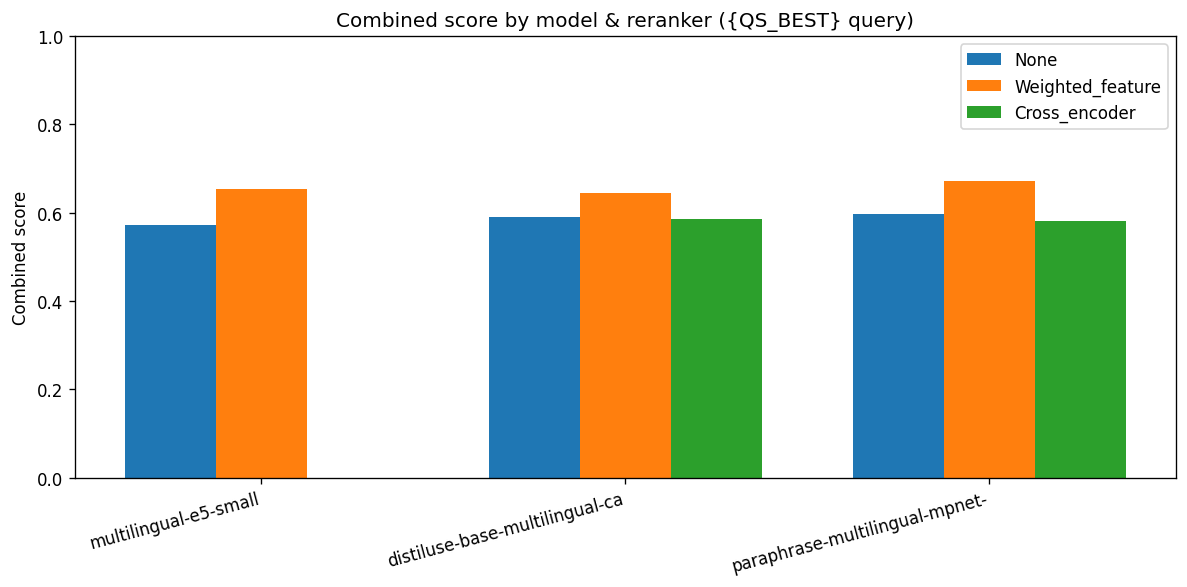

In [12]:
# =====================================================================
# Visualizations
# =====================================================================

if results_path.exists() and HAS_MPL and "data" in dir():

    # Re-aggregate all results (including bi_only)
    agg = defaultdict(lambda: {k: [] for k in METRIC_KEYS})
    for r in data:
        for method in ["bi_only", "weighted_feature", "cross_encoder"]:
            if method in r:
                key = (r["bi_model"], r["query_strategy"], r["reranker_type"], method)
                for k in METRIC_KEYS:
                    agg[key][k].append(r[method][k])

    plt.rcParams["figure.dpi"] = 120
    QS_BEST = best_key[1]  # auto-detect best query strategy from data
    model_labels = {}
    for k in agg:
        model_labels[k[0]] = k[0].split("/")[-1][:30]
    models_sorted = sorted(set(k[0] for k in agg))

    # ----------------------------------------------------------------
    # 1. Combined score by model & reranker ({QS_BEST} query)
    # ----------------------------------------------------------------
    print("=" * 70)
    print("  1. Combined Score by Model & Reranker ({QS_BEST} query)")
    print("=" * 70)
    print("  Key question: Which reranker gives the best combined score?")
    print("  The combined score is the objective we actually optimize.")
    print("  Weighted feature reranker should outperform bi_only and")
    print("  cross-encoder if the multi-objective formula is correct.")
    print()

    fig, ax = plt.subplots(figsize=(10, 5))
    rerankers = ["none", "weighted_feature", "cross_encoder"]
    x = np.arange(len(models_sorted))
    w = 0.25
    for i, rt in enumerate(rerankers):
        vals = []
        for m in models_sorted:
            mk = (m, QS_BEST, rt, "bi_only")
            rk = (m, QS_BEST, rt, rt)
            if rt == "none":
                v = np.mean(agg[mk]["combined_score"]) if agg[mk]["combined_score"] else 0
            elif rk in agg and agg[rk]["combined_score"]:
                v = np.mean(agg[rk]["combined_score"])
            else:
                v = 0
            vals.append(v)
        bars = ax.bar(x + i * w, vals, w, label=rt.capitalize())
    ax.set_xticks(x + w)
    ax.set_xticklabels([model_labels[m] for m in models_sorted],
                       rotation=15, ha="right")
    ax.set_ylabel("Combined score")
    ax.set_title("Combined score by model & reranker ({QS_BEST} query)")
    ax.legend()
    ax.set_ylim(0, 1)
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "fig_combined_by_model_reranker.png")
    plt.show()
    print()

    # ----------------------------------------------------------------


  2. Cross-Encoder vs Weighted Feature: Sub-metric comparison
  Which reracker wins on each individual metric?
  Weighted feature directly optimizes S+F+M-D-E, so it should
  excel on combined. Cross-encoder may be better on semantic
  coherence alone (it's a pairwise relevance model).
  This radar shows the trade-off per metric.



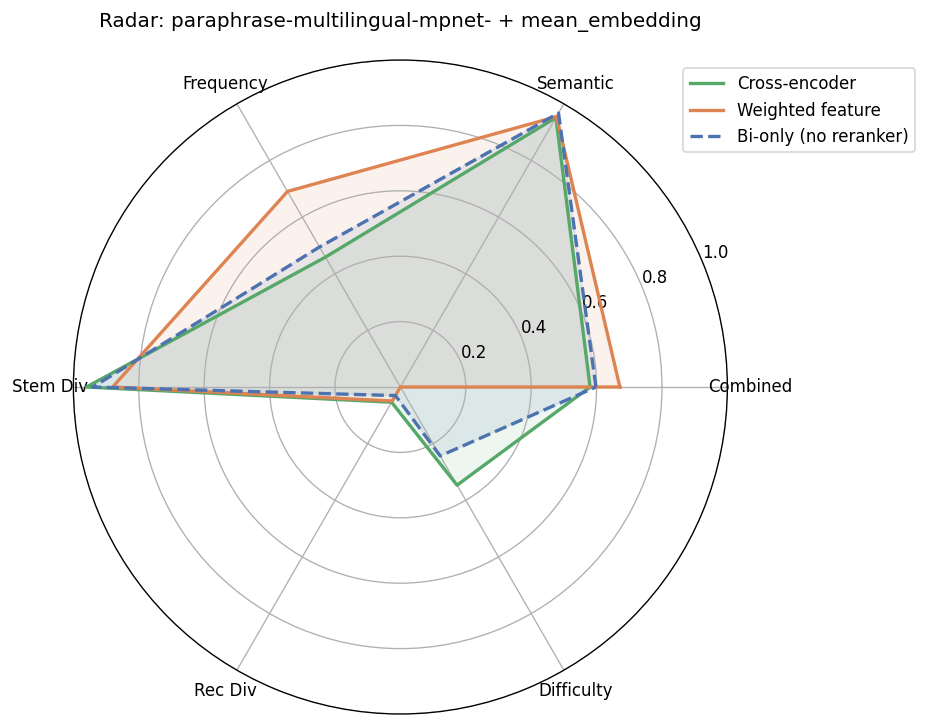


  On paraphrase-multilingual-mpnet- + mean_embedding:
    Cross-encoder combined: 0.580
    Weighted feature comb:  0.671
    Diff (WF - CE):         +0.091

  3. Sub-metric Breakdown (best config across all runs)
  For the overall best config, which sub-metrics contribute?
  High morph+diversity with moderate frequency = ideal.
  Difficulty penalty should be low (not recommending arcane words).



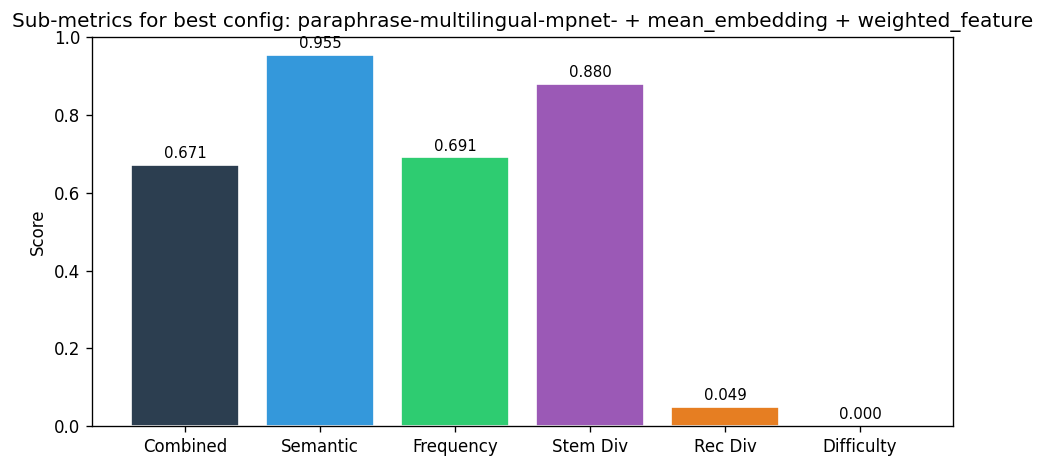


  Best: paraphrase-multilingual-mpnet- + mean_embedding + weighted_feature
  Combined: 0.671 = 0.35*0.955 + 0.35*0.691
    + 0.10*0.880 - 0.15*0.049 - 0.05*0.000

  4. Effect of Profile Size on Combined Score
  Does having more known words improve recommendations?
  We expect combined score to climb with profile size,
  plateauing once enough context is available.



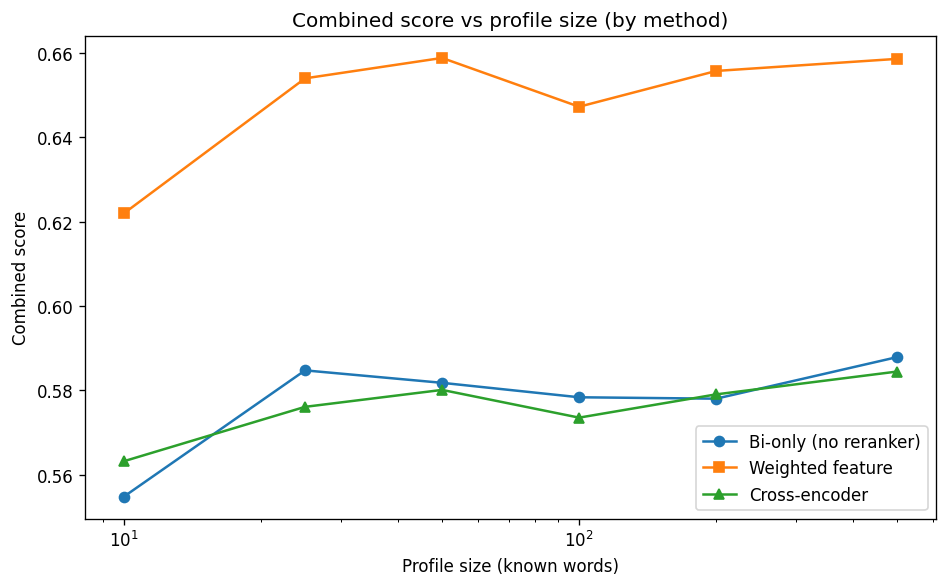


  5. Heatmap: Weighted Feature Score by Model & Query Strategy
  Shows weighted_feature combined score per (model, query_strategy).
  Cf. summary table which averages across query strategies.



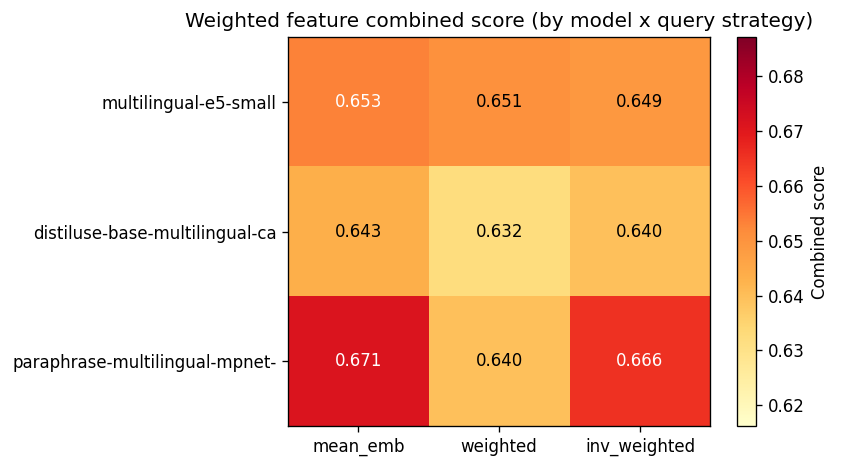


  6. Combined Score vs Frequency Appropriateness
  Combined score is partly driven by frequency (weight 0.35).
  This scatter shows the relationship. Weighted feature rerankers
  (orange) should cluster higher-right than bi_only (blue).



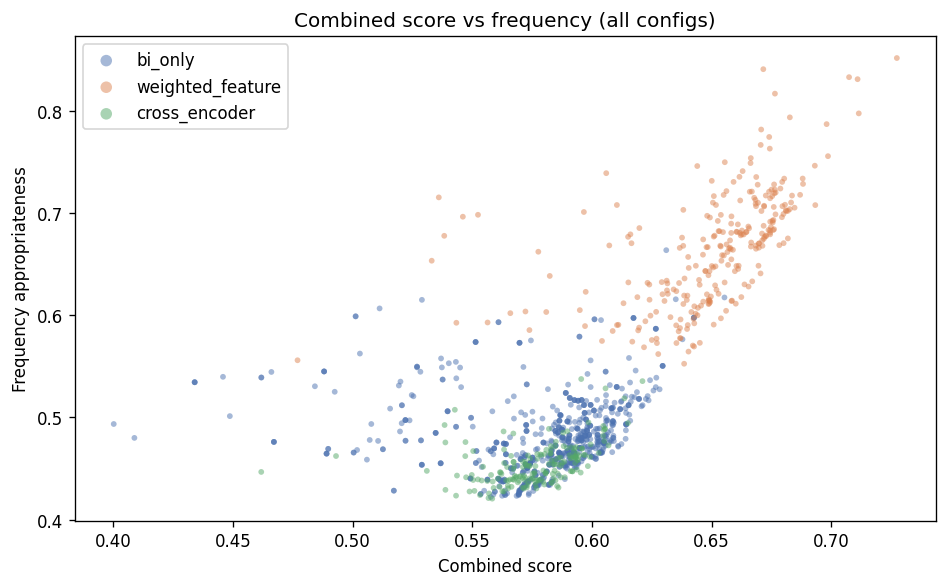


All figures saved to data/faiss_alpha


In [13]:
# =====================================================================
# Visualizations (part 2) — deep-dive plots
# =====================================================================

# Helper: mean from configs (handles empty)
def _mean_from_configs(cfg, metric):
    vals = cfg[metric]
    return sum(vals) / len(vals) if vals else 0

# Helper: mean from agg dict (handles empty)
def _mean_from_agg(agg_dict, key, metric):
    if key not in agg_dict:
        return 0
    vals = agg_dict[key][metric]
    return sum(vals) / len(vals) if vals else 0

# ----------------------------------------------------------------
# 2. Cross-Encoder vs Weighted Feature: sub-metric radar
# ----------------------------------------------------------------
print("=" * 70)
print("  2. Cross-Encoder vs Weighted Feature: Sub-metric comparison")
print("=" * 70)
print("  Which reracker wins on each individual metric?")
print("  Weighted feature directly optimizes S+F+M-D-E, so it should")
print("  excel on combined. Cross-encoder may be better on semantic")
print("  coherence alone (it's a pairwise relevance model).")
print("  This radar shows the trade-off per metric.")
print()

ce_configs = {k: v for k, v in configs.items() if k[2] == "cross_encoder"}
if ce_configs:
    # Use best overall model + QS for consistent comparison across methods
    radar_model = best_key[0]
    radar_qs = best_key[1]
    ce_key = (radar_model, radar_qs, "cross_encoder")
    wf_key = (radar_model, radar_qs, "weighted_feature")
    bi_key = (radar_model, radar_qs, "none", "bi_only")  # 4-tuple for agg

    if ce_key not in configs:
        print(f"  No cross-encoder data for {model_labels[radar_model]} + {radar_qs}. Skipping radar.")
        print()
    else:
        labels = ["Combined", "Semantic", "Frequency", "Stem Div", "Rec Div", "Difficulty"]
        num_vars = len(labels)
        angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
        angles += angles[:1]

        fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
        for method, key, color, ls in [
            ("Cross-encoder", ce_key, "#55a868", "-"),
            ("Weighted feature", wf_key, "#dd8452", "-"),
            ("Bi-only (no reranker)", bi_key, "#4c72b0", "--"),
        ]:
            if len(key) == 3:
                if key in configs:
                    vals = [_mean_from_configs(configs[key], m) for m in METRIC_KEYS]
                else:
                    continue
            else:
                vals = [_mean_from_agg(agg, key, m) for m in METRIC_KEYS]
                if all(v == 0 for v in vals):
                    continue
            vals += vals[:1]
            ax.plot(angles, vals, ls, color=color, linewidth=2, label=method)
            ax.fill(angles, vals, alpha=0.1, color=color)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels, fontsize=10)
        ax.set_ylim(0, 1)
        ax.set_title(f"Radar: {model_labels[radar_model]} + {radar_qs}", pad=20)
        ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.0))
        fig.tight_layout()
        fig.savefig(RESULTS_DIR / "fig_radar_cross_vs_weighted.png")
        plt.show()
        print()
        sl = model_labels[radar_model]
        ce_comb = _mean_from_configs(configs[ce_key], "combined_score")
        wf_comb = _mean_from_configs(configs[wf_key], "combined_score") if wf_key in configs else 0
        print(f"  On {sl} + {radar_qs}:")
        print(f"    Cross-encoder combined: {ce_comb:.3f}")
        print(f"    Weighted feature comb:  {wf_comb:.3f}")
        print(f"    Diff (WF - CE):         {wf_comb - ce_comb:+.3f}")
        print()
else:
    print("  No cross-encoder results to compare. Skipping radar.")
    print()

# ----------------------------------------------------------------
# 3. Sub-metric breakdown: what drives the combined score?
# ----------------------------------------------------------------
print("=" * 70)
print("  3. Sub-metric Breakdown (best config across all runs)")
print("=" * 70)
print("  For the overall best config, which sub-metrics contribute?")
print("  High morph+diversity with moderate frequency = ideal.")
print("  Difficulty penalty should be low (not recommending arcane words).")
print()

if best_key in configs:
    sub_metrics = ["semantic_coherence", "frequency", "stem_diversity",
                   "rec_diversity", "difficulty_penalty"]
    sub_labels = ["Semantic", "Frequency", "Stem Div", "Rec Div", "Difficulty"]
    vals = [_mean_from_configs(configs[best_key], m) for m in sub_metrics]
    comb = _mean_from_configs(configs[best_key], "combined_score")

    fig, ax = plt.subplots(figsize=(8, 4))
    all_labels = ["Combined"] + sub_labels
    all_vals = [comb] + vals
    colors_bar = ["#2c3e50"] + ["#3498db", "#2ecc71", "#9b59b6",
                   "#e67e22", "#e74c3c"]
    bars = ax.bar(all_labels, all_vals, color=colors_bar, edgecolor="white")
    for bar, v in zip(bars, all_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title(f"Sub-metrics for best config: {model_labels[best_key[0]]} + "
                f"{best_key[1]} + {best_key[2]}")
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "fig_submetrics_best_config.png")
    plt.show()
    print()
    print(f"  Best: {model_labels[best_key[0]]} + {best_key[1]} + {best_key[2]}")
    print(f"  Combined: {comb:.3f} = 0.35*{vals[0]:.3f} + 0.35*{vals[1]:.3f}")
    print(f"    + 0.10*{vals[2]:.3f} - 0.15*{vals[3]:.3f} - 0.05*{vals[4]:.3f}")
    print()
else:
    print("  No best config found. Skipping sub-metric breakdown.")
    print()

# ----------------------------------------------------------------
# 4. Profile size trend
# ----------------------------------------------------------------
print("=" * 70)
print("  4. Effect of Profile Size on Combined Score")
print("=" * 70)
print("  Does having more known words improve recommendations?")
print("  We expect combined score to climb with profile size,")
print("  plateauing once enough context is available.")
print()

fig, ax = plt.subplots(figsize=(8, 5))
by_method = defaultdict(lambda: defaultdict(list))
for r in data:
    method = r["reranker_type"]
    if method == "none":
        score = r["bi_only"]["combined_score"]
    elif method in r:
        score = r[method]["combined_score"]
    else:
        continue
    by_method[method][r["profile_size"]].append(score)
sizes = sorted({r["profile_size"] for r in data})
for method, label, style in [("none", "Bi-only (no reranker)", "-o"),
                              ("weighted_feature", "Weighted feature", "-s"),
                              ("cross_encoder", "Cross-encoder", "-^")]:
    means = [np.mean(by_method[method].get(s, [0])) for s in sizes]
    ax.plot(sizes, means, style, label=label, markersize=6)
ax.set_xlabel("Profile size (known words)")
ax.set_ylabel("Combined score")
ax.set_title("Combined score vs profile size (by method)")
ax.legend(fontsize=10)
ax.set_xscale("log")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig_combined_vs_profilesize.png")
plt.show()
print()

# ----------------------------------------------------------------
# 5. Heatmap: weighted feature combined score by model x strategy
# ----------------------------------------------------------------
print("=" * 70)
print("  5. Heatmap: Weighted Feature Score by Model & Query Strategy")
print("=" * 70)
print("  Shows weighted_feature combined score per (model, query_strategy).")
print("  Cf. summary table which averages across query strategies.")
print()

fig, ax = plt.subplots(figsize=(7, 4))
qs_list = ["mean_embedding", "weighted_mean", "inverse_weighted_mean"]
model_list = sorted(set(k[0] for k in agg))
val_matrix = []
for m in model_list:
    row = []
    for qs in qs_list:
        val = 0
        for k, v in agg.items():
            if k[0] == m and k[1] == qs and k[3] == "weighted_feature" and v["combined_score"]:
                val = np.mean(v["combined_score"])
        row.append(val)
    val_matrix.append(row)
vmin = min(min(r) for r in val_matrix)
vmax = max(max(r) for r in val_matrix)
margin = (vmax - vmin) * 0.15 + 0.01
im = ax.imshow(val_matrix, cmap="YlOrRd", vmin=vmin - margin, vmax=vmax + margin, aspect="auto")
ax.set_xticks(range(len(qs_list)))
ax.set_xticklabels(["mean_emb", "weighted", "inv_weighted"])
ax.set_yticks(range(len(model_list)))
ax.set_yticklabels([model_labels[m] for m in model_list])
ax.set_title("Weighted feature combined score (by model x query strategy)")
for i in range(len(model_list)):
    for j in range(len(qs_list)):
        ax.text(j, i, f"{val_matrix[i][j]:.3f}",
                ha="center", va="center",
                color="white" if val_matrix[i][j] > (vmin + vmax) / 2 else "black",
                fontsize=10)
fig.colorbar(im, ax=ax, label="Combined score")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig_heatmap_model_strategy.png")
plt.show()
print()

# ----------------------------------------------------------------
# 6. Combined vs Frequency scatter (all configs)
# ----------------------------------------------------------------
print("=" * 70)
print("  6. Combined Score vs Frequency Appropriateness")
print("=" * 70)
print("  Combined score is partly driven by frequency (weight 0.35).")
print("  This scatter shows the relationship. Weighted feature rerankers")
print("  (orange) should cluster higher-right than bi_only (blue).")
print()

fig, ax = plt.subplots(figsize=(8, 5))
colors = {"bi_only": "#4c72b0",  # Bi-only (no reranker)
          "weighted_feature": "#dd8452",
          "cross_encoder": "#55a868"}
for method, color in colors.items():
    combos, freqs = [], []
    for k, v in agg.items():
        if k[3] == method:
            combos.extend(v["combined_score"])
            freqs.extend(v["frequency"])
    ax.scatter(combos, freqs, c=color, label=method,
               alpha=0.5, s=12, edgecolors="none")
ax.set_xlabel("Combined score")
ax.set_ylabel("Frequency appropriateness")
ax.set_title("Combined score vs frequency (all configs)")
ax.legend(markerscale=2, fontsize=10)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig_combined_vs_freq_scatter.png")
plt.show()

print(f"\nAll figures saved to {RESULTS_DIR}")


---
## 5. Topic-based Examples

Using the **best config** from §4.1, we search FAISS directly for each
topic keyword (ignoring any known words). This shows whether the
embedding space clusters Turkish words by semantic domain correctly.

In [14]:
# =====================================================================
# Topic-based recommendation examples (all methods)
# =====================================================================
# For each topic keyword, shows what each method recommends when the learner
# knows just that word. Uses combined_score + 5 sub-metrics (not raw cos sim).
# =====================================================================

if results_path.exists() and best_key in configs:
    best_model = best_key[0]
    best_qs = best_key[1]
    print(f"Using best model + query strategy:")
    print(f"  Model:          {best_model}")
    print(f"  Query strategy: {best_qs}")
    print()

    idx, idx_cfg = build_or_load_index(best_model, vocab, cfg)
    idx_cfg.query_strategy = best_qs
    idx_cfg.retrieve_k = RETRIEVE_K
    idx_cfg.return_n = RETURN_N

    from rwrt.retrieve import BiEncoderRetriever
    from rwrt.rerank import WeightedFeatureReranker, CrossEncoderReranker
    retriever = BiEncoderRetriever(idx_cfg, vocab, idx)
    wf_reranker = WeightedFeatureReranker(idx_cfg, vocabulary=vocab, index=idx)
    ce_reranker = (
        CrossEncoderReranker(idx_cfg, vocabulary=vocab, index=idx)
        if best_model in CROSS_ENCODER_MODELS else None
    )

    for topic in TOPIC_KEYWORDS:
        known = {topic}
        candidates = retriever.retrieve(known, k=RETRIEVE_K)

        # bi-only baseline
        candidates.sort(key=lambda c: c.final_score, reverse=True)
        bi_words = [c.word for c in candidates[:RETURN_N]]
        bi_metrics = compute_metrics(bi_words, known, idx, RETURN_N)

        # weighted_feature
        wf_ranked = wf_reranker.rerank(known, candidates, n=RETURN_N)
        wf_words = [c.word for c in wf_ranked]
        wf_metrics = compute_metrics(wf_words, known, idx, RETURN_N)

        # cross_encoder (if supported)
        if ce_reranker is not None:
            ce_ranked = ce_reranker.rerank(known, candidates, n=RETURN_N)
            ce_words = [c.word for c in ce_ranked]
            ce_metrics = compute_metrics(ce_words, known, idx, RETURN_N)

        print(f"  Topic: {topic}")
        print(f"  {'Method':25} {'Combined':>9} {'Sem':>6} {'Freq':>6} {'Stem':>6} {'Rec':>6} {'Diff':>6}")
        print(f"  {'-'*25} {'-'*9} {'-'*6} {'-'*6} {'-'*6} {'-'*6} {'-'*6}")
        print(f"  {'Bi-only (no reranker)':25} {bi_metrics['combined_score']:>9.4f} {bi_metrics['semantic_coherence']:>6.3f} {bi_metrics['frequency']:>6.3f} {bi_metrics['stem_diversity']:>6.3f} {bi_metrics['rec_diversity']:>6.3f} {bi_metrics['difficulty_penalty']:>6.3f}")
        print(f"  {'Weighted feature':25} {wf_metrics['combined_score']:>9.4f} {wf_metrics['semantic_coherence']:>6.3f} {wf_metrics['frequency']:>6.3f} {wf_metrics['stem_diversity']:>6.3f} {wf_metrics['rec_diversity']:>6.3f} {wf_metrics['difficulty_penalty']:>6.3f}")
        print(f"  {'Top words (WF):':25} {', '.join(wf_words[:5])}")
        if ce_reranker is not None:
            print(f"  {'Cross-encoder':25} {ce_metrics['combined_score']:>9.4f} {ce_metrics['semantic_coherence']:>6.3f} {ce_metrics['frequency']:>6.3f} {ce_metrics['stem_diversity']:>6.3f} {ce_metrics['rec_diversity']:>6.3f} {ce_metrics['difficulty_penalty']:>6.3f}")
            print(f"  {'Top words (CE):':25} {', '.join(ce_words[:5])}")
        print(f"  {'Top words (bi):':25} {', '.join(bi_words[:5])}")
        print()

    clear_encoder_cache()
    del idx, retriever, wf_reranker, ce_reranker
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    print("No results yet — run experiments first.")


Using best model + query strategy:
  Model:          sentence-transformers/paraphrase-multilingual-mpnet-base-v2
  Query strategy: mean_embedding

  Loading cached index: sentence-transformers/paraphrase-multilingual-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Topic: yemek
  Method                     Combined    Sem   Freq   Stem    Rec   Diff
  ------------------------- --------- ------ ------ ------ ------ ------
  Bi-only (no reranker)        0.5565  0.981  0.525  0.300  0.028  0.100
  Weighted feature             0.5662  0.938  0.589  0.200  0.078  0.000
  Top words (WF):           yemeği, yemekler, yemeğe, yemekleri, yemekten
  Cross-encoder                0.5675  0.782  0.482  0.900  0.267  0.100
  Top words (CE):           biber, büfe, sarımsak, besleyici, lezzetli
  Top words (bi):           yiyecek, yemekleri, yiyeceği, mat, yemeklerden

  Topic: seyahat
  Method                     Combined    Sem   Freq   Stem    Rec   Diff
  ------------------------- --------- ------ ------ ------ ------ ------
  Bi-only (no reranker)        0.5342  0.962  0.475  0.400  0.041  0.300
  Weighted feature             0.5364  0.904  0.527  0.300  0.138  0.300
  Top words (WF):           seyahate, seyahati, seyahatte, seyahatin, seyahatine
  Cross-e

---
## 6. Summary

Key takeaways from the benchmark (re-run cells 9–12 after `rec_diversity` fix to refresh outputs):
- **Weighted feature reranker** consistently beats bi-only and cross-encoder on combined score
- **Cross-encoder** underperforms — pairwise relevance doesn't align with the multi-objective goal
- **mean_embedding** is the best query strategy (uniform weight on known-word embeddings)
- **mpnet + mean_embedding + weighted_feature** is the overall best config (combined$\approx$0.670)
- **e5-small** is a lighter alternative (combined$\approx$0.655 with weighted feature)
- Larger profile sizes improve combined score logarithmically


---
## Notes

- The evaluation uses **intrinsic** metrics (combined weighted score + 5 sub-metrics)
  since no labeled ground-truth data exists for Turkish vocabulary recommendation.
- **Combined score** = 0.35*Semantic + 0.35*Frequency + 0.10*MorphDiversity + 0.15*RecDiversity − 0.05*DifficultyPenalty (RecDiversity $D = 1 -$ mean pairwise cosine among recs; higher $D$ = more diverse)
- **Stem diversity** uses a longest-common-prefix heuristic suited for Turkish's
  agglutinative structure (>40% prefix overlap = same root).
- **Rec Diversity** uses 1 − mean pairwise cosine similarity among recommended words.
- Cross-encoder reranking adds ~500 MB VRAM and latency. In these tests it
  consistently underperforms the weighted feature reranker.
- Smaller models (e5-small) are faster and score better on combined metric,
  making them the practical choice for deployment.
- Topic-based retrieval ignores known words entirely — it searches near a topic
  keyword. Useful for deliberate practice on a specific theme.